# Week 3: Backpropagation and Stochastic Gradient Descent

## Implementing Backpropagation

Below, we implement a fully-connected feedforward neural network with random weight initialization, customizable architecture, and gradient descent with use of backpropagation for computing the gradients. We will then test it on some examples.

The best way to understand how this all works is to actually implement it with minimal external libraries. One exception is `NumPy`, which at least automates some of the basic mathematical operations we need to do.

In [1]:
import numpy as np

Next, we will implement the feedforward neural network. The code is partly based on an implementation from *Deep Learning for Computer Vision with Python* by Adrian Rosebrock.

In [2]:
class FeedforwardNeuralNetwork:
    
    # input a vector [a, b, c, ...] with the number of nodes in each layer
    def __init__(self, layers, alpha = 0.1):
        
        # list of weight matrices between layers
        self.W = []
        
        # network architecture will be a vector of numbers of nodes for each layer
        self.layers = layers
        
        # learning rate
        self.alpha = alpha
        
        # initialize the weights (randomly) -- this is our initial guess for gradient descent
        
        # initialize the weights between layers (up to the next-to-last one) as normal random variables
        for i in np.arange(0, len(layers) - 2):
            self.W.append(np.random.randn(layers[i] + 1, layers[i + 1] + 1))
            
        # initialize weights between the last two layers (we don't want bias for the last one)
        self.W.append(np.random.randn(layers[-2] + 1, layers[-1]))
        
    # define the sigmoid activation
    def sigmoid(self, x):
        return 1.0 / (1 + np.exp(-x))
    
    # define the sigmoid derivative (where z is the output of a sigmoid)
    def sigmoidDerivative(self, z):
        return z * (1 - z)
    
    # fit the model
    def fit(self, X, y, epochs = 10000, update = 1000):
        # add a column of ones to the end of X
        X = np.hstack((X, np.ones([X.shape[0],1])))

        for epoch in np.arange(0,epochs):

            # feed forward, backprop, and weight update
            for (x, target) in zip(X, y):
                
                # make a list of output activations from the first layer
                # (just the original x values)
                A = [np.atleast_2d(x)]
                
                # feed forward
                for layer in np.arange(0, len(self.W)):
                    
                    # feed through one layer and apply sigmoid activation
                    net = A[layer].dot(self.W[layer])
                    out = self.sigmoid(net)
                    
                    # add our network output to the list of activations
                    A.append(out)
                    
                # backpropagation
                error = A[-1] - target
                
                # term proportional to the gradient
                D = [error * self.sigmoidDerivative(A[-1])]
                
                # loop backwards over the layers to build up deltas
                for layer in np.arange(len(A) - 2, 0, -1):
                    delta = D[-1].dot(self.W[layer].T)
                    delta = delta * self.sigmoidDerivative(A[layer])
                    D.append(delta)
                    
                # reverse the deltas since we looped in reverse
                D = D[::-1]
                
                # weight update
                for layer in np.arange(0, len(self.W)):
                    self.W[layer] -= self.alpha * A[layer].T.dot(D[layer])
                    
            # print a status update
            if (epoch + 1) % update == 0:
                loss = self.computeLoss(X,y)
                print('Epoch =', epoch + 1, 'loss = ', loss)
                
    def predict(self, X, addOnes = True):
        # initialize data, be sure it's the right dimension
        p = np.atleast_2d(X)
        
        # add a column of 1s for bias
        if addOnes:
            p = np.hstack((p, np.ones([X.shape[0],1])))
        
        # feed forward!
        for layer in np.arange(0, len(self.W)):
            p = self.sigmoid(np.dot(p, self.W[layer]))
         
        # return the predictions
        return p
    
    def computeLoss(self, X, y):
        # initialize data, be sure it's the right dimension
        y = np.atleast_2d(y)
        
        # feed the datapoints through the network to get predicted outputs
        predictions = self.predict(X, addOnes = False)
        
        # compute the sum of squared errors loss function
        loss = np.sum((predictions - y)**2) / 2.0
        
        return loss

Let's check the variables of the model.

In [3]:
model = FeedforwardNeuralNetwork([2, 2, 1])
vars(model)

{'W': [array([[-1.23970453, -1.15690062,  0.2682631 ],
         [-0.36539424, -0.42286025, -1.03639424],
         [ 0.55351142, -0.24680762, -1.51238209]]),
  array([[-0.19849983],
         [ 0.55075371],
         [ 0.71884318]])],
 'layers': [2, 2, 1],
 'alpha': 0.1}

### Example: XOR function

Let's run the code to try to learn the exclusive 'or' function, i.e. XOR.

In [4]:
import random

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

model.fit(X,y,50000,1000)

Epoch = 1000 loss =  0.4688696140609588
Epoch = 2000 loss =  0.3133132135742095
Epoch = 3000 loss =  0.19338968173778845
Epoch = 4000 loss =  0.15672113034548918
Epoch = 5000 loss =  0.1442929815484842
Epoch = 6000 loss =  0.13851967574601215
Epoch = 7000 loss =  0.13526856503449589
Epoch = 8000 loss =  0.13320510738396577
Epoch = 9000 loss =  0.13178566163557714
Epoch = 10000 loss =  0.13075099306621615
Epoch = 11000 loss =  0.1299628099954701
Epoch = 12000 loss =  0.1293408497896684
Epoch = 13000 loss =  0.12883530415780908
Epoch = 14000 loss =  0.1284134531615681
Epoch = 15000 loss =  0.12805262052698674
Epoch = 16000 loss =  0.12773615108410216
Epoch = 17000 loss =  0.1274508744782657
Epoch = 18000 loss =  0.12718522556199185
Epoch = 19000 loss =  0.12692741058312415
Epoch = 20000 loss =  0.1266628385945661
Epoch = 21000 loss =  0.12636912438122075
Epoch = 22000 loss =  0.1260035618727024
Epoch = 23000 loss =  0.12546309685319995
Epoch = 24000 loss =  0.12440659857673902
Epoch = 25

In [5]:
model.predict(X)

array([[0.02225864],
       [0.98180798],
       [0.97963219],
       [0.01776341]])

Note these are very close to 0, 1, 1, 0 -- the correct classifications for the XOR function. This neural net can classify this nonlinear problem of XOR.

### Example: Tiny MNIST

In [6]:
# load some more libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import datasets
from tensorflow.keras.utils import to_categorical

2026-06-01 16:34:33.428973: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-01 16:34:34.109196: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-01 16:34:35.920037: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Let's try to classify a tiny version of the MNIST data shrunk down to 8-by-8 pixel images.

In [7]:
### CLASSIFY MNIST PICTURES

# 'digits' is a tiny version of MNIST in sklearn.datasets has only 8 x 8 pixels
# with grayscale values from 0 to 16
digits = datasets.load_digits()
data = digits.data.astype("float")
print("Samples: {}, Dimension: {}".format(data.shape[0], data.shape[1]))

X = data

Y = digits.target

# randomly choose 75% of the data to be the training set and 25% for the testing set
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

# we need to turn the labels into 1-hot representations
trainY = to_categorical(trainY)
testY = to_categorical(testY)

# fit the model to the training data
model = FeedforwardNeuralNetwork([64, 16, 10])
model.fit(trainX, trainY, 1000, 100)

# print the classification performance
print("Training set accuracy")

predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)

print(classification_report(trainY, predictedY))

print("Test set accuracy")

predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)

print(classification_report(testY, predictedY))

Samples: 1797, Dimension: 64
Epoch = 100 loss =  53.24869530532599
Epoch = 200 loss =  28.110567451328286
Epoch = 300 loss =  22.15681812079235
Epoch = 400 loss =  20.71587069200363
Epoch = 500 loss =  19.661249588197585
Epoch = 600 loss =  18.548787401510168
Epoch = 700 loss =  18.025476749122816
Epoch = 800 loss =  17.71545442007313
Epoch = 900 loss =  17.4867123923647
Epoch = 1000 loss =  17.197212973544772
Training set accuracy
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       138
           1       0.99      0.99      0.99       136
           2       0.98      1.00      0.99       127
           3       1.00      0.96      0.98       140
           4       0.98      0.99      0.99       141
           5       1.00      0.98      0.99       133
           6       1.00      0.98      0.99       133
           7       1.00      1.00      1.00       126
           8       0.93      0.99      0.96       135
           9       0.99

Let's try the same with two hidden layers.

In [8]:
### CLASSIFY MNIST PICTURES

# 'digits' is a tiny version of MNIST in sklearn.datasets has only 8 x 8 pixels
# with grayscale values from 0 to 16
digits = datasets.load_digits()
data = digits.data.astype("float")
print("Samples: {}, Dimension: {}".format(data.shape[0], data.shape[1]))

X = data/16.0

Y = digits.target

# randomly choose 75% of the data to be the training set and 25% for the testing set
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

# we need to turn the labels into 1-hot representations
trainY = to_categorical(trainY)
testY = to_categorical(testY)

# fit the model to the training data
model = FeedforwardNeuralNetwork([64, 32, 16, 10])
model.fit(trainX, trainY, 1000, 10)

# print the classification performance
print("Training set accuracy")

predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)

print(classification_report(trainY, predictedY))

print("Test set accuracy")

predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)

print(classification_report(testY, predictedY))

Samples: 1797, Dimension: 64
Epoch = 10 loss =  89.42043987229059
Epoch = 20 loss =  38.49828614125902
Epoch = 30 loss =  23.298652785062966
Epoch = 40 loss =  16.21096383653788
Epoch = 50 loss =  11.804389102593223
Epoch = 60 loss =  8.69529497021102
Epoch = 70 loss =  6.474915000813536
Epoch = 80 loss =  5.085305149803714
Epoch = 90 loss =  4.137885499679488
Epoch = 100 loss =  3.3611999958312273
Epoch = 110 loss =  2.8706936799642535
Epoch = 120 loss =  2.525966040985027
Epoch = 130 loss =  2.260915831870323
Epoch = 140 loss =  2.035239136312621
Epoch = 150 loss =  1.6193657514675026
Epoch = 160 loss =  1.3623566742521245
Epoch = 170 loss =  1.2182443488391677
Epoch = 180 loss =  1.1068089023766183
Epoch = 190 loss =  1.0153242964757265
Epoch = 200 loss =  0.9380701850759384
Epoch = 210 loss =  0.8716641516500914
Epoch = 220 loss =  0.8138446303521232
Epoch = 230 loss =  0.7629923045515781
Epoch = 240 loss =  0.7178961793164326
Epoch = 250 loss =  0.6776228654414362
Epoch = 260 loss

Almost all test images were labeled correctly, 97%! But let's take a look at the ones that were labeled wrong. Most look a bit ambiguous or messy, so it's not that surprising they were not classified correctly.

60
The correct label is 3
The predicted label is 2
61
The correct label is 9
The predicted label is 5
139
The correct label is 9
The predicted label is 5
142
The correct label is 9
The predicted label is 3
147
The correct label is 7
The predicted label is 8
163
The correct label is 9
The predicted label is 3
166
The correct label is 8
The predicted label is 1
173
The correct label is 9
The predicted label is 3
199
The correct label is 8
The predicted label is 1
246
The correct label is 1
The predicted label is 0
260
The correct label is 3
The predicted label is 9
365
The correct label is 3
The predicted label is 5
372
The correct label is 7
The predicted label is 8
435
The correct label is 7
The predicted label is 9


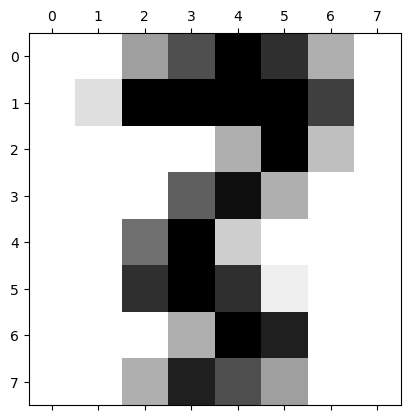

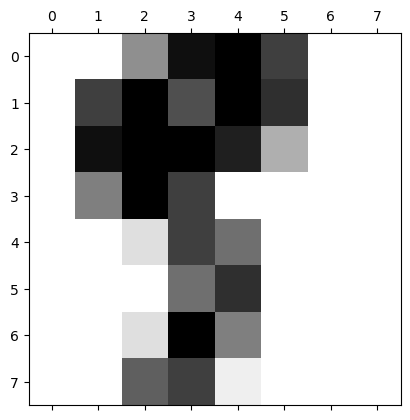

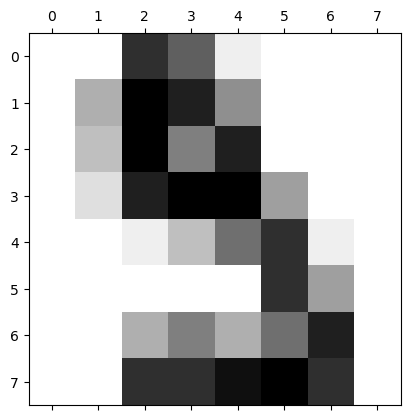

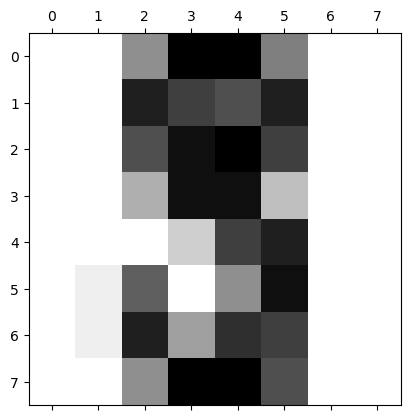

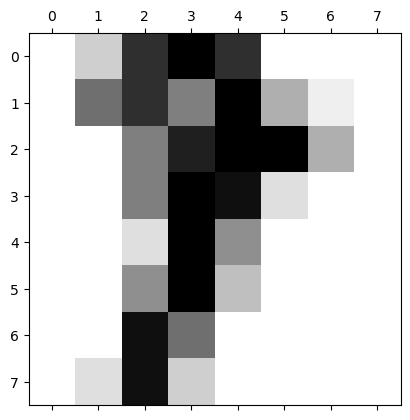

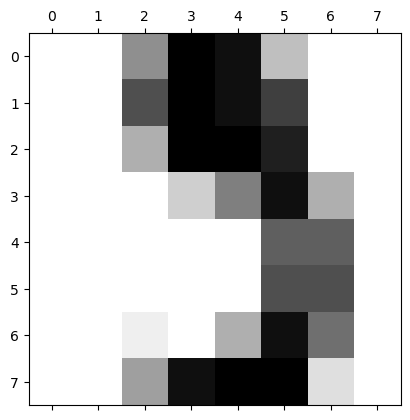

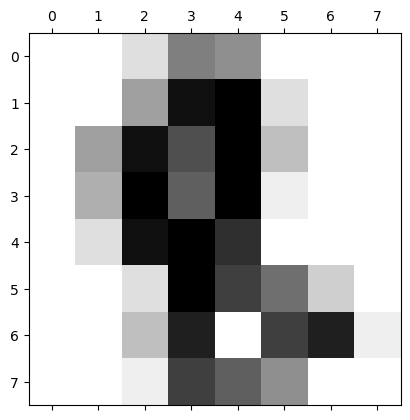

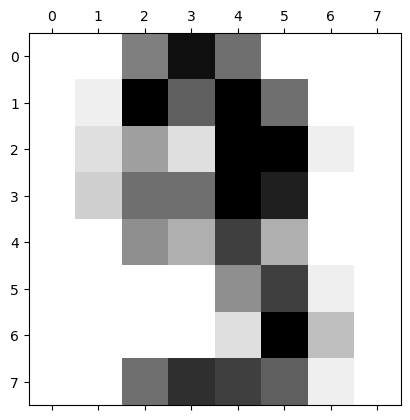

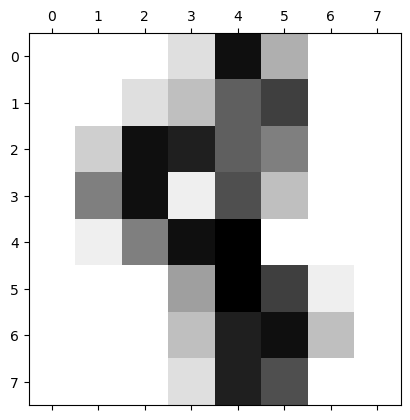

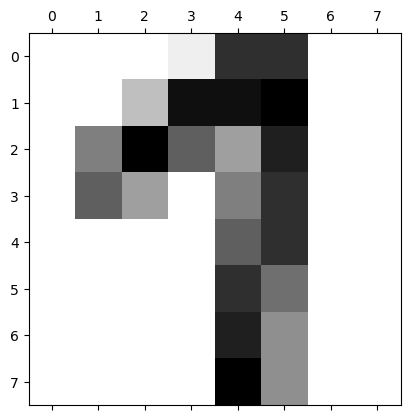

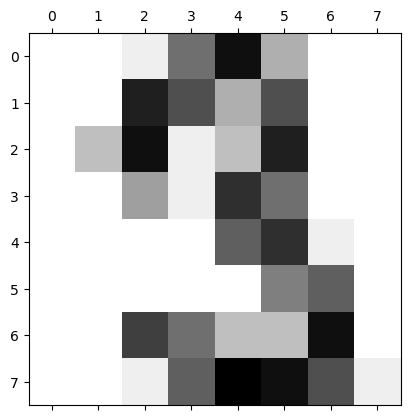

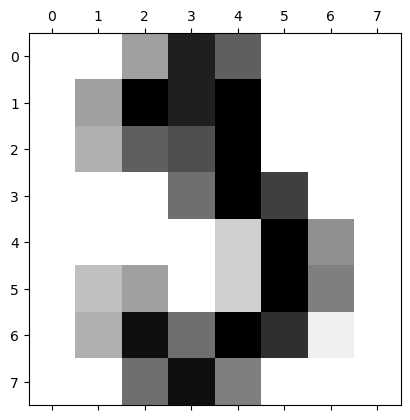

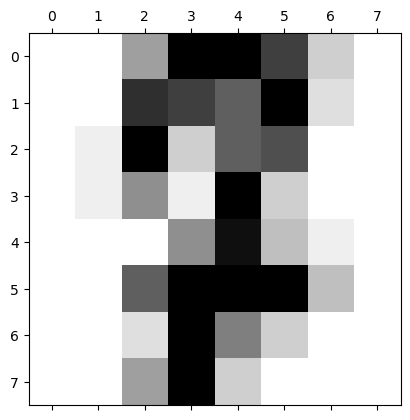

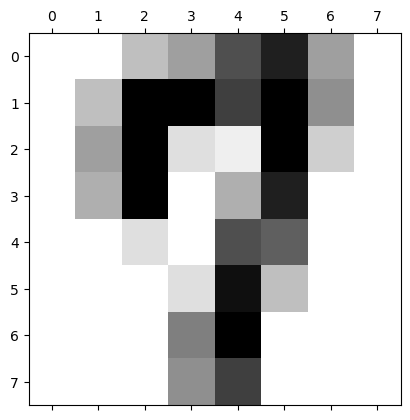

In [9]:
import matplotlib.pyplot as plt

for i in range(testX.shape[0]):
    if testY[i] != predictedY[i]:
        print(i)
        print('The correct label is', testY[i])
        print('The predicted label is', predictedY[i])
        plt.matshow(16*testX[i].reshape(8,8), cmap='gray_r')

Some of these images are really hard to interpret, even as a human, so it is unsurprising the model has trouble with them.

### Example: Full-Size MNIST

Next, let's try to use 1000 images from the full-sized MNIST dataset of 28-by-28 grayscale images.

In [10]:
from tensorflow.keras.datasets import mnist

In [11]:
### CLASSIFY MNIST PICTURES

# create a dataset of 1000 MNIST images, reshaped as single vectors, and labels
data = mnist.load_data()

# The datapoints are in mnistData[0][0]
X = data[0][0][:1000].reshape([1000,28*28])
X = X/255.0

# The labels are in mnistData[0][1]
Y = data[0][1][:1000]

# randomly choose 75% of the data to be the training set and 25% for the testing set
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

trainY = to_categorical(trainY)
testY = to_categorical(testY)

# fit the model to the training data
model = FeedforwardNeuralNetwork([784, 16, 10], 0.5)
model.fit(trainX, trainY, 1000, 100)

# print the classification performance
print("Training set accuracy")
predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)
print(classification_report(trainY, predictedY))

print("Test set accuracy")
predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)
print(classification_report(testY, predictedY))

Epoch = 100 loss =  7.748746970274369
Epoch = 200 loss =  5.6124665929108755
Epoch = 300 loss =  5.371150458852526
Epoch = 400 loss =  5.262810805131192
Epoch = 500 loss =  5.197620262482623
Epoch = 600 loss =  5.141709756212663
Epoch = 700 loss =  5.109658901308553
Epoch = 800 loss =  5.0920812113352625
Epoch = 900 loss =  5.079768295681184
Epoch = 1000 loss =  5.070374883898783
Training set accuracy
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        68
           1       0.98      0.99      0.98        84
           2       1.00      0.98      0.99        82
           3       0.97      1.00      0.99        74
           4       0.99      1.00      0.99        79
           5       1.00      0.96      0.98        69
           6       1.00      0.99      0.99        73
           7       0.98      1.00      0.99        86
           8       1.00      1.00      1.00        61
           9       0.97      0.96      0.97        74


Here, we have an **overfitting** problem because the training accuracy is good, but test accuracy is significantly worse. This frequently happens when we use a small dataset. In this case, we used only 1000 images, but it still took a several minutes to run. If we used 10000 images, which would be a more ideal dataset, it would take 30-40 minutes!

This is no good... we need stochastic gradient descent to make this more useful on larger datasets.

## Speeding Up Learning (SGD, cross-entropy)

We already know what gradient descent is: we run our model on training data, compute the loss function, find the gradient of the loss function, and update our parameters in the opposite direction of the gradient by a small amount; and repeat this until the model converges. The same general approach is used in nearly all neural networks.

In linear regression and logistic classification, we were computing the outputs and loss function for the entire dataset (usually multiple times) per iteration of gradient descent, making a weight update based on the gradient, and repeating.

The typical approach used in modern neural networks is **stochastic** gradient descent (SGD). SGD updates weights after processing a random sample, called a **mini-batch**, of datapoints: enough points to reduce the variance of using just one for more stable convergence of parameters but not so much that the computation is too expensive. In this way, we process a mini-batch for outputs, compute an approximate loss function and approximate gradients, update weights, and repeat.

### How large should our mini-batches be?

Typically, using $2^n$ for something like $n=5, 6, 7, 8$ because these values tend to be ideal for the linear algebra optimization libraries we use (NumPy, TensorFlow, etc). The mini-batch size is a hyperparameter, but it generally isn't one you need to tweak too much.

One exception is if you are using GPUs for computing: then, it's typically best to choose the largest power of 2 that allows a whole mini-batch to fit into GPU memory, which will result in the underlying linear algebra libraries working optimally.

### Implementing SGD

Once we implement SGD with backpropagation, we will have constructed a "vanilla" neural network, which is probably the simplest neural network that is of practical use.

First, let's import some libraries we will be using.

In [12]:
# load some libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.datasets import mnist
from keras.utils import to_categorical

Next, we will write a class similar to the `FeedforwardNeuralNetwork` class we wrote previously but upgraded to use SGD.

In [13]:
class FeedforwardNeuralNetworkSGD:
    
    # input a vector [a, b, c, ...] with the number of nodes in each layer
    def __init__(self, layers, alpha = 0.1, batchSize = 32):
        # list of weight matrices between layers
        self.W = []
        
        # network architecture will be a vector of numbers of nodes for each layer
        self.layers = layers
        
        # learning rate
        self.alpha = alpha
        
        # batch size
        self.batchSize = batchSize
        
        # initialize the weights (randomly) -- this is our initial guess for gradient descent
        
        # initialize the weights between layers (up to the next-to-last one) as normal random variables
        for i in np.arange(0, len(layers) - 2):
            self.W.append(np.random.randn(layers[i] + 1, layers[i + 1] + 1))
            
        # initialize weights between the last two layers (we don't want bias for the last one)
        self.W.append(np.random.randn(layers[-2] + 1, layers[-1]))
        
    # define the sigmoid activation
    def sigmoid(self, x):
        return 1.0 / (1 + np.exp(-x))
    
    # define the sigmoid derivative (where z is the output of a sigmoid)
    def sigmoidDerivative(self, z):
        return z * (1 - z)
    
    # get a new mini-batch of data from the dataset
    def getNextBatch(self, X, y, batchSize):
        for i in np.arange(0, X.shape[0], batchSize):
            # yield returns a generator, which can continue where it left off on later calls
            # of the function
            yield (X[i:i + batchSize], y[i:i + batchSize])
    
    # fit the model
    def fit(self, X, y, epochs = 10000, update = 1000):
        # add a column of ones to the end of X
        X = np.hstack((X, np.ones([X.shape[0],1])))

        for epoch in range(epochs):
            
            # randomize the examples
            p = np.arange(0, X.shape[0])
            np.random.shuffle(p)
            X = X[p]
            y = y[p]

            # feed forward, backprop, and weight update
            for (x, target) in self.getNextBatch(X, y, self.batchSize):
                
                # make a list of output activations from the first layer
                # (just the original x values)
                A = [np.atleast_2d(x)]
                
                # feed forward
                for layer in range(len(self.W)):
                    
                    # feed through one layer and apply sigmoid activation
                    net = A[layer].dot(self.W[layer])
                    out = self.sigmoid(net)
                    
                    # add our network output to the list of activations
                    A.append(out)
                    
                # backpropagation (coming soon!)
                error = A[-1] - target
                
                D = [error * self.sigmoidDerivative(A[-1])]
                
                # loop backwards over the layers to build up deltas
                for layer in np.arange(len(A) - 2, 0, -1):
                    delta = D[-1].dot(self.W[layer].T)
                    delta = delta * self.sigmoidDerivative(A[layer])
                    D.append(delta)
                    
                # reverse the deltas since we looped in reverse
                D = D[::-1]
                
                # weight update in each layer
                for layer in range(len(self.W)):
                    self.W[layer] -= self.alpha * A[layer].T.dot(D[layer])
                    
            # print an 
            if (epoch + 1) % update == 0:
                loss = self.computeLoss(X,y)
                print('Epoch =', epoch + 1, '\t loss =', loss)
                
    def predict(self, X, addOnes = True):
        # initialize data, be sure it's the right dimension
        p = np.atleast_2d(X)
        
        # add a column of 1s for bias
        if addOnes:
            p = np.hstack((p, np.ones([X.shape[0],1])))
        
        # feed forward!
        for layer in np.arange(0, len(self.W)):
            p = self.sigmoid(np.dot(p, self.W[layer]))
            
        return p
    
    def computeLoss(self, X, y):
        # initialize data, be sure it's the right dimension
        y = np.atleast_2d(y)
        
        # feed the datapoints through the network to get predicted outputs
        predictions = self.predict(X, addOnes = False)
        loss = np.sum((predictions - y)**2) / 2.0
        
        return loss

### Example: MNIST

As promised, this SGD neural net should run faster, so let's try to use the full 60,000 training images available in MNIST and 10,000 test images. (This is still a LOT of computation, using 70000 total 28-by-28 images.

In [14]:
### CLASSIFY MNIST PICTURES

# load the full MNIST dataset: both data and labels
((trainX, trainY), (testX, testY)) = mnist.load_data()

# scale the data to values in [0,1]
trainX = trainX.astype('float32')/255.0
testX = testX.astype('float32')/255.0

# reshape the data
trainX = trainX.reshape([60000, 28*28])
testX = testX.reshape([10000, 28*28])

# convert the digits to one-hot vectors
trainY = to_categorical(trainY, 10)
testY = to_categorical(testY, 10)

# fit the model to the training data
model = FeedforwardNeuralNetworkSGD([784, 32, 16, 10], 0.5, 32)
model.fit(trainX, trainY, 100, 1)

# print the classification performance
print("Training set accuracy")
predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)
print(classification_report(trainY, predictedY))

print("Test set accuracy")
predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)
print(classification_report(testY, predictedY))

Epoch = 1 	 loss = 4654.387505932153
Epoch = 2 	 loss = 3610.4392856201393
Epoch = 3 	 loss = 3630.307619873552
Epoch = 4 	 loss = 3217.056183201571
Epoch = 5 	 loss = 2876.8683811271258
Epoch = 6 	 loss = 2961.0707156779636
Epoch = 7 	 loss = 2726.5935448398577
Epoch = 8 	 loss = 2793.6543968252954
Epoch = 9 	 loss = 2597.244739026215
Epoch = 10 	 loss = 2863.8956710262773
Epoch = 11 	 loss = 2623.1140143043435
Epoch = 12 	 loss = 2488.0576662339795
Epoch = 13 	 loss = 2493.9252838875445
Epoch = 14 	 loss = 2358.057698084657
Epoch = 15 	 loss = 2249.195503733793
Epoch = 16 	 loss = 2412.5079724890834
Epoch = 17 	 loss = 2095.7306126438793
Epoch = 18 	 loss = 2344.462198569316
Epoch = 19 	 loss = 2257.8875588652904
Epoch = 20 	 loss = 2264.1078028492875
Epoch = 21 	 loss = 2071.0402178871955
Epoch = 22 	 loss = 2159.735970694218
Epoch = 23 	 loss = 2049.1343506913618
Epoch = 24 	 loss = 1996.0592490775089
Epoch = 25 	 loss = 2123.7370104096535
Epoch = 26 	 loss = 2144.367106182942
Epoc

Our test accuracy on MNIST jumped from mid-80\% previously to 95\% with our implementation using SGD and the full dataset!

### Cross-Entropy Loss Function

We will discuss in class, but the cross-entropy loss function can lead to faster training than the SSE we have used before, so we add it to the implementation.

In [15]:
class FeedforwardNeuralNetworkSGD:
    
    # input a vector [a, b, c, ...] with the number of nodes in each layer
    def __init__(self, layers, alpha = 0.1, batchSize = 32, loss = 'sum-of-squares'):
        # list of weight matrices between layers
        self.W = []
        
        # network architecture will be a vector of numbers of nodes for each layer
        self.layers = layers
        
        # learning rate
        self.alpha = alpha
        
        # batch size
        self.batchSize = batchSize
        
        # loss function
        self.loss = loss
        
        # initialize the weights (randomly) -- this is our initial guess for gradient descent
        
        # initialize the weights between layers (up to the next-to-last one) as normal random variables
        for i in np.arange(0, len(layers) - 2):
            self.W.append(np.random.randn(layers[i] + 1, layers[i + 1] + 1))
            
        # initialize weights between the last two layers (we don't want bias for the last one)
        self.W.append(np.random.randn(layers[-2] + 1, layers[-1]))
        
    # define the sigmoid activation
    def sigmoid(self, x):
        return 1.0 / (1 + np.exp(-x))
    
    # define the sigmoid derivative (where z is the output of a sigmoid)
    def sigmoidDerivative(self, z):
        return z * (1 - z)
    
    # get a new mini-batch of data from the dataset
    def getNextBatch(self, X, y, batchSize):
        for i in np.arange(0, X.shape[0], batchSize):
            # yield returns a generator, which can continue where it left off on later calls
            # of the function
            yield (X[i:i + batchSize], y[i:i + batchSize])
    
    # fit the model
    def fit(self, X, y, epochs = 10000, update = 1000):
        # add a column of ones to the end of X
        X = np.hstack((X, np.ones([X.shape[0],1])))

        for epoch in range(epochs):
            
            # randomize the examples
            p = np.arange(0, X.shape[0])
            np.random.shuffle(p)
            X = X[p]
            y = y[p]

            # feed forward, backprop, and weight update
            for (x, target) in self.getNextBatch(X, y, self.batchSize):
                
                # make a list of output activations from the first layer
                # (just the original x values)
                A = [np.atleast_2d(x)]
                
                # feed forward
                for layer in range(len(self.W)):
                    
                    # feed through one layer and apply sigmoid activation
                    net = A[layer].dot(self.W[layer])
                    out = self.sigmoid(net)
                    
                    # add our network output to the list of activations
                    A.append(out)
                    
                # backpropagation (coming soon!)
                error = A[-1] - target
                
                if self.loss == 'sum-of-squares':
                    D = [error * self.sigmoidDerivative(A[-1])]
                    
                if self.loss == 'cross-entropy':
                    D = [error]
                    
                # loop backwards over the layers to build up deltas
                for layer in np.arange(len(A) - 2, 0, -1):
                    delta = D[-1].dot(self.W[layer].T)
                    delta = delta * self.sigmoidDerivative(A[layer])
                    D.append(delta)
                    
                # reverse the deltas since we looped in reverse
                D = D[::-1]
                
                # weight update in each layer
                for layer in range(len(self.W)):
                    self.W[layer] -= self.alpha * A[layer].T.dot(D[layer])
                    
            # print an 
            if (epoch + 1) % update == 0:
                loss = self.computeLoss(X,y)
                print('Epoch =', epoch + 1, '\t loss =', loss)
                
    def predict(self, X, addOnes = True):
        # initialize data, be sure it's the right dimension
        p = np.atleast_2d(X)
        
        # add a column of 1s for bias
        if addOnes:
            p = np.hstack((p, np.ones([X.shape[0],1])))
        
        # feed forward!
        for layer in np.arange(0, len(self.W)):
            p = self.sigmoid(np.dot(p, self.W[layer]))
            
        return p
    
    def computeLoss(self, X, y):
        # initialize data, be sure it's the right dimension
        y = np.atleast_2d(y)
        
        # feed the datapoints through the network to get predicted outputs
        predictions = self.predict(X, addOnes = False)
        
        # if the loss function is sum of squares, compute it
        if self.loss == 'sum-of-squares':
            loss = np.sum((predictions - y)**2) / 2.0
            
        # if the loss function is cross-entropy, compute it
        if self.loss == 'cross-entropy':
            loss = np.sum(np.nan_to_num(-y * np.log(predictions) - (1 - y) * np.log(1 - predictions)))
        
        return loss

In [16]:
### CLASSIFY MNIST PICTURES

# load the full MNIST dataset: both data and labels
((trainX, trainY), (testX, testY)) = mnist.load_data()

# scale the data to values in [0,1]
trainX = trainX.astype('float32')/255.0
testX = testX.astype('float32')/255.0

# reshape the data
trainX = trainX.reshape([60000, 28*28])
testX = testX.reshape([10000, 28*28])

# convert the digits to one-hot vectors
trainY = to_categorical(trainY, 10)
testY = to_categorical(testY, 10)

# fit the model to the training data
model = FeedforwardNeuralNetworkSGD([784, 32, 16, 10], 0.1, 32, 'cross-entropy')
model.fit(trainX, trainY, 100, 1)

# print the classification performance
print("Training set accuracy")
predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)
print(classification_report(trainY, predictedY))

print("Test set accuracy")
predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)
print(classification_report(testY, predictedY))

Epoch = 1 	 loss = 31479.32116850843
Epoch = 2 	 loss = 24450.96470988336
Epoch = 3 	 loss = 21945.876552420104
Epoch = 4 	 loss = 20771.94294328764
Epoch = 5 	 loss = 18875.68197720546
Epoch = 6 	 loss = 18512.279197892458
Epoch = 7 	 loss = 19659.825378459067
Epoch = 8 	 loss = 18462.222293726172
Epoch = 9 	 loss = 18566.193157218837
Epoch = 10 	 loss = 16819.491868625595
Epoch = 11 	 loss = 18005.497675069877
Epoch = 12 	 loss = 17248.684238668477
Epoch = 13 	 loss = 15513.005133259327
Epoch = 14 	 loss = 15432.639984866213
Epoch = 15 	 loss = 15354.77700147993
Epoch = 16 	 loss = 16437.311278442674
Epoch = 17 	 loss = 15492.562063169618
Epoch = 18 	 loss = 14567.708206977775
Epoch = 19 	 loss = 13899.628348280597
Epoch = 20 	 loss = 13866.118928639447
Epoch = 21 	 loss = 15354.509543254788
Epoch = 22 	 loss = 14314.677664441746
Epoch = 23 	 loss = 14177.412230449389
Epoch = 24 	 loss = 12757.60420848205
Epoch = 25 	 loss = 13208.333621955719
Epoch = 26 	 loss = 13087.34425899702
Ep

We get similar to slightly better results here.